In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns 
import scanpy as sc

from readcount_tools import PAPER_CONTEXT, PAGEWIDTH_IN, SMALL_SIZE,MEDIUM_SIZE,BIGGER_SIZE,LINEWIDTH,POINTSIZE,TICKLENGTH,LEGEND_FONTSIZE,SPINEWIDTH,LETTER_LOC_X,LETTER_LOC_Y
from sklearn import linear_model

In [2]:
import pickle

In [3]:
basepath = 'data/tasic/'

In [4]:
with open(f'{basepath}cluster_df.pickle','rb') as f:
    cluster_df = pickle.load(f)
with open(f'{basepath}adatas_by_cluster.pickle','rb') as f:
    adatas_by_cluster = pickle.load(f)

In [5]:
cluster_df['cluster_class_plot'] = cluster_df.cluster_class.copy()

In [6]:
def compute_cell_stats(adata):
    X = adata.X
    if hasattr(X, "toarray"):
        X = X.toarray()
    
    avg_total_counts = np.mean(X.sum(axis=1))
    avg_nonzero_genes = np.mean((X > 0).sum(axis=1))
    
    return avg_total_counts, avg_nonzero_genes

In [7]:
non_neuronal_idx = cluster_df.cluster_class.isin(['Endothelial','Non-Neuronal'])
cluster_df.loc[non_neuronal_idx,'cluster_class_plot']='Non-Neuronal'

In [8]:
def plot_estimate_ez(ad,ax,mean_varkey,fraczero_varkey,xmin=0.1,xmax=200,yticks=[-1,-5],plot=False):
    
    
    x=ad.var[mean_varkey].values
    y=ad.var[fraczero_varkey].values
    frac_zero_0_idx = y==0
    mean_larger_1_idx = (ad.var[mean_varkey].values < xmax) & (ad.var[mean_varkey].values > xmin)

    x = x[~frac_zero_0_idx & mean_larger_1_idx]
    y = y[~frac_zero_0_idx & mean_larger_1_idx]

    xmax_fit=xmax
    
    logy=np.log(y)

    lm = linear_model.LinearRegression(fit_intercept=False)
    lm.fit(x.reshape(-1, 1),logy)
    slope = lm.coef_[0]

    if plot:
        ax.scatter(x,logy,s=POINTSIZE,lw=0,rasterized=True)

    x_fit = np.arange(0,xmax_fit)
    y_fit = slope*x_fit
    
    E_Z = 1/(-slope)

    if plot:
        ax.plot(x_fit,y_fit,'k',label=r'$E_Z$ = -1/slope = ' f'{E_Z:.1f}',lw=LINEWIDTH)
        ax.set_yticks(yticks)
        leg=ax.legend(frameon=True,fontsize=LEGEND_FONTSIZE)
        leg.get_frame().set_linewidth(0.0)
        ax.set_ylabel('log(fraction of zeros)')
    
    return E_Z

In [9]:
ezs=[]
avg_counts=[]
avg_ngenes=[]
for ad in adatas_by_cluster:
    # print(ad.uns['clustername'],ad.shape)
    ezs.append(plot_estimate_ez(ad=ad,ax=None,mean_varkey='gene_mean_withinCluster',fraczero_varkey='gene_fraction_zeros_withinCluster'))
    avg_c, avg_n = compute_cell_stats(ad)
    avg_counts.append(avg_c)
    avg_ngenes.append(avg_n)
cluster_df['ez']=ezs
cluster_df['avg_counts']=np.array(avg_counts)/1e6
cluster_df['avg_ngenes']=avg_ngenes

In [10]:
cluster_df.loc[cluster_df.ez>150,:].head()

,name,ncells,ngenes,color,level1,level2,cluster_class,cluster_id,cluster_class_plot,ez,avg_counts,avg_ngenes
115,Meis2 Adamts19,56,21885,#FF0000,Meis2,Adamts19,GABAergic,115,GABAergic,156.931652,1.395953,4996.982143
116,CR Lhx5,18,16529,#00FF66,CR,Lhx5,Glutamatergic,116,Glutamatergic,152.467832,1.225531,4908.333333
117,Astro Aqp4,583,28309,#665C47,Astro,Aqp4,Non-Neuronal,117,Non-Neuronal,155.790835,1.167344,3996.662093
118,OPC Pdgfra Grm5,52,20168,#476655,OPC,Pdgfra,Non-Neuronal,118,Non-Neuronal,216.599161,1.361350,4191.750000
121,Oligo Serpinb1a,83,19531,#6C8581,Oligo,Serpinb1a,Non-Neuronal,121,Non-Neuronal,189.312874,1.653579,3995.506024


In [11]:
ncols = 2
nrows = 2
panelheight = PAGEWIDTH_IN/ncols
figheight_in = panelheight*nrows

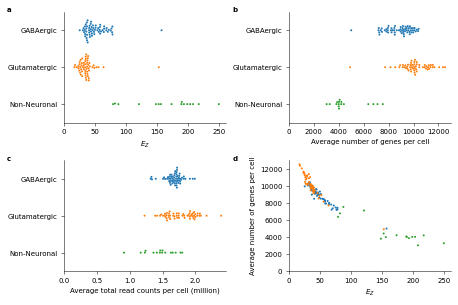

In [12]:
with mpl.rc_context(PAPER_CONTEXT):
    
    fig,axes = plt.subplots(2,2,figsize=(PAGEWIDTH_IN,figheight_in*0.66),constrained_layout=True)

    axes=axes.flatten()
    size=2
    ax=axes[0]
    sns.swarmplot(data=cluster_df, x="ez", y="cluster_class_plot", hue="cluster_class_plot", ax=ax,size=size)

    ax.legend_.remove()
    ax.set_xlabel(r'$E_Z$ ')
    ax.set_ylabel('')
    ax.set_xlim(left=0)

    ax=axes[1]
    sns.swarmplot(data=cluster_df, x="avg_ngenes", y="cluster_class_plot", hue="cluster_class_plot", ax=ax,size=size)

    ax.legend_.remove()
    ax.set_xlabel('Average number of genes per cell')
    ax.set_ylabel('')
    ax.set_xlim(left=0)

    ax=axes[2]
    sns.swarmplot(data=cluster_df, x="avg_counts", y="cluster_class_plot", hue="cluster_class_plot", ax=ax,size=size)

    ax.legend_.remove()
    ax.set_xlabel('Average total read counts per cell (million)')
    ax.set_ylabel('')
    # ax.set_xticks([0,1000000,2000000])
    ax.set_xlim(left=0)
    
    from matplotlib.ticker import ScalarFormatter

    formatter = ScalarFormatter()
    formatter.set_scientific(False)
    formatter.set_useOffset(False)
    ax.xaxis.set_major_formatter(formatter)


    ax=axes[3]
    sns.scatterplot(data=cluster_df, x="ez", y="avg_ngenes", hue="cluster_class_plot",ax=ax,linewidth=0,s=size*2)
    plt.xlabel(r'$E_{Z}$')
    plt.ylabel('Average number of genes per cell')
    ax.legend_.remove()
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    
    
    for ax in axes.flatten():
        for axis in ['bottom','left']:
            ax.spines[axis].set_linewidth(SPINEWIDTH)
        
    letters=['a','b',
             'c','d',]
    for ax,letter, in zip(axes.flatten(),letters):
        ax.text(LETTER_LOC_X-0.05,LETTER_LOC_Y+0.05,letter,transform=ax.transAxes,fontweight='bold')
    

    sns.despine()
    plt.show()
    
    fig.savefig('figures/S_tasic_estimate_eZ_per_cell_type.pdf', dpi=300, format=None, bbox_inches = 'tight')